### Download YOLO Formatted file of Non-Seasonal Vegetable Dataset


In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="J1rWUvuwvKwOyLI5ooEK")
project = rf.workspace("sanjana-kazi-supti-ymhu2").project("non-seasonal-vegetable-detection-yms0u")
version = project.version(3)
dataset = version.download("yolov12")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 64.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, 


Extracting Dataset Version Zip to Non-Seasonal-Vegetable-Detection-3 in yolov12:: 100%|██████████| 9606/9606 [00:01<00:00, 9081.07it/s] 


### Install ultralytics supervision and Roboflow. Then check for the CUDA

In [2]:
!pip install ultralytics --no-deps
import ultralytics
ultralytics.checks()

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6842.1/8062.4 GB disk)


In [3]:
!pip install pycocotools tqdm


In [4]:
import os
import shutil
import json
from pathlib import Path
import yaml
from ultralytics import YOLO

In [5]:
# !pip install --quiet --upgrade numpy==1.25.2 scipy==1.10.1 scikit-learn==1.3.2 ultralytics pyyaml pandas matplotlib opencv-python


## Visualize Some Annotated images

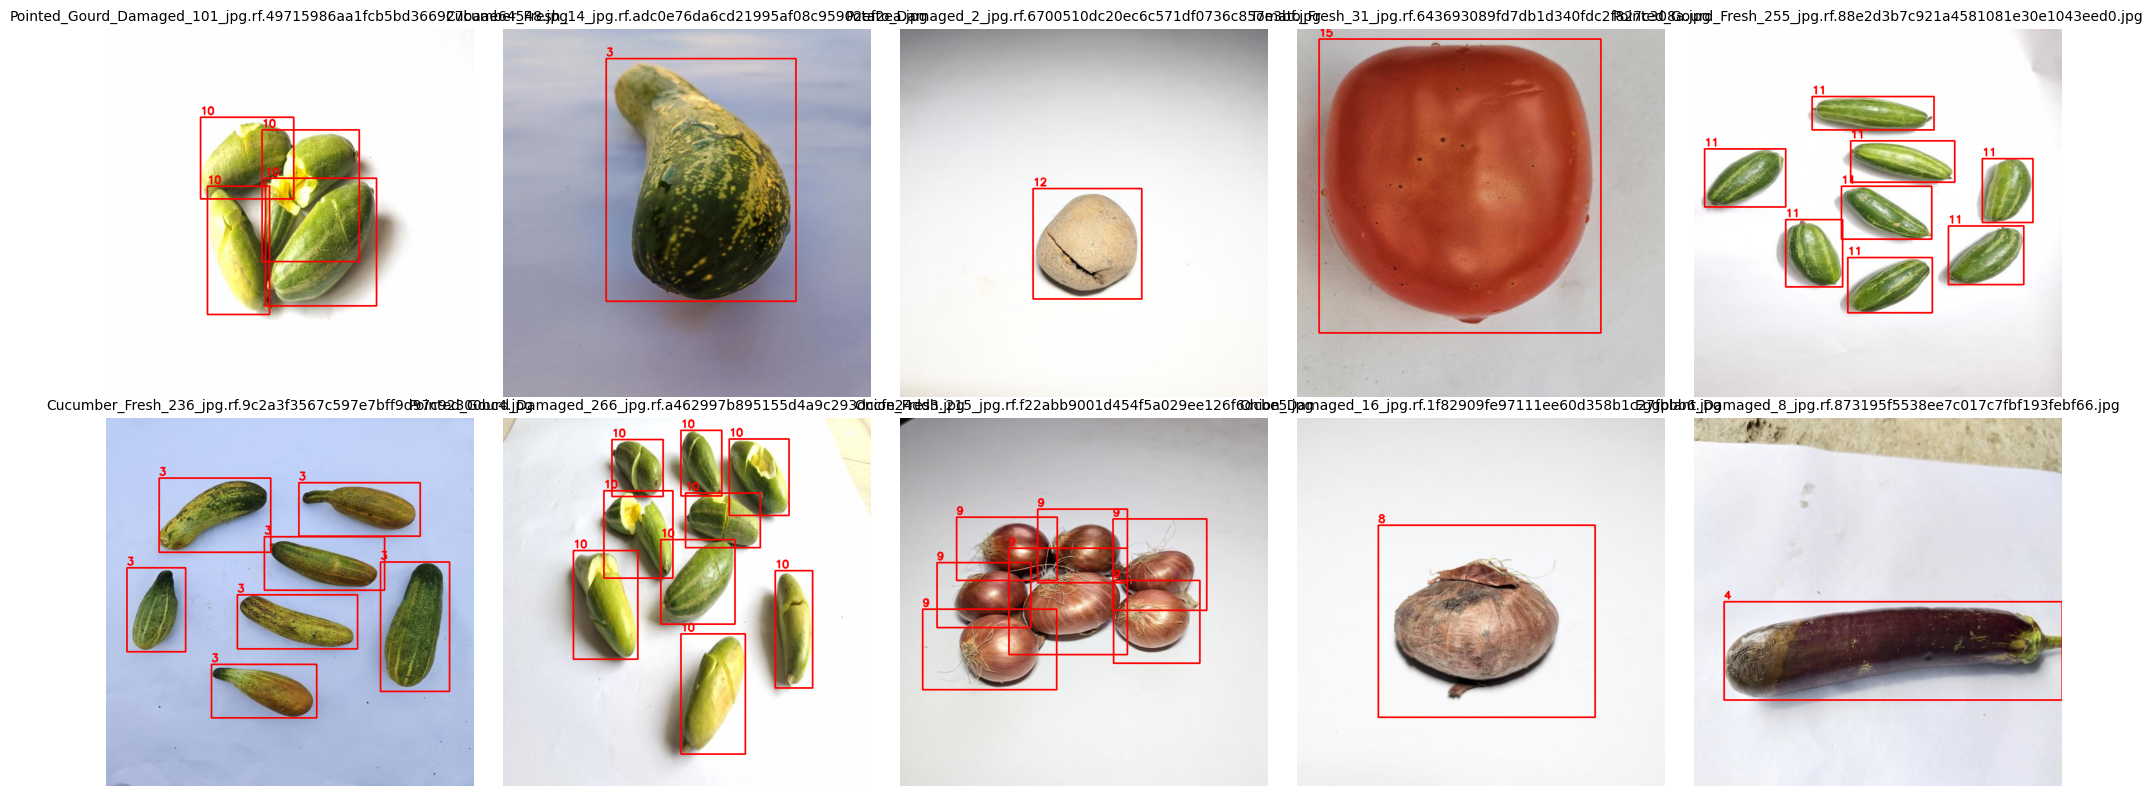

In [6]:
import cv2
import matplotlib.pyplot as plt
import random

WORK = Path("/kaggle/working/Non-Seasonal-Vegetable-Detection-3")

# ----------------------------------------------------------------------------
# 2. Visualize Converted YOLO Annotations
# ----------------------------------------------------------------------------

def draw_yolo_bbox(img_path, label_path):
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    if not label_path.exists():
        return image  # No label file

    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, x_c, y_c, bw, bh = map(float, line.strip().split())
            x1 = int((x_c - bw / 2) * w)
            y1 = int((y_c - bh / 2) * h)
            x2 = int((x_c + bw / 2) * w)
            y2 = int((y_c + bh / 2) * h)
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(image, str(int(cls)), (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return image

# Pick 10 random images from the converted train split
img_dir = WORK / "train" / "images"
lbl_dir = WORK / "train" / "labels"
img_files = list(img_dir.glob("*.jpg"))
sample_files = random.sample(img_files, min(10, len(img_files)))

# Plot 2 rows of 5 images
plt.figure(figsize=(20, 8))
for idx, img_path in enumerate(sample_files):
    label_path = lbl_dir / f"{img_path.stem}.txt"
    img = draw_yolo_bbox(img_path, label_path)
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.title(img_path.name, fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [7]:
!pip install --quiet --upgrade numpy==1.25.2 scipy==1.10.1 scikit-learn==1.3.2
!pip install ultralytics --no-deps
import ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 27.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# YOLO v10

## 1. Train

In [8]:
# ================= FINAL FIXED K-FOLD YOLO =================

import os
import shutil
from pathlib import Path
from sklearn.model_selection import KFold
from ultralytics import YOLO
import yaml
import pandas as pd
import numpy as np
import torch

# ----------------------------------------------------------------------------
# 1. CONFIG
# ----------------------------------------------------------------------------
WORK = Path("/kaggle/working/Non-Seasonal-Vegetable-Detection-3")
YAML_PATH = WORK / "data.yaml"

K_FOLDS = 5
EPOCHS = 50
BATCH_SIZE = 12
IMG_SIZE = 640

DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ----------------------------------------------------------------------------
# 2. LOAD YAML
# ----------------------------------------------------------------------------
with open(YAML_PATH, "r") as f:
    data_yaml = yaml.safe_load(f)

# Clean class names
if isinstance(data_yaml.get("names"), list):
    data_yaml["names"] = list(dict.fromkeys(data_yaml["names"]))

# ----------------------------------------------------------------------------
# 3. FIX PATHS (WORKING VERSION)
# ----------------------------------------------------------------------------

BASE = Path("/kaggle/working/Non-Seasonal-Vegetable-Detection-3")

train_path = BASE / "train" / "images"
val_path   = BASE / "valid" / "images"

print("Train path:", train_path)
print("Exists:", train_path.exists())

if not train_path.exists():
    raise ValueError("❌ Train path still wrong")

# ----------------------------------------------------------------------------
# 4. LOAD IMAGES (FIXED - RECURSIVE)
# ----------------------------------------------------------------------------
all_images = sorted(
    list(train_path.rglob("*.jpg")) +
    list(train_path.rglob("*.png")) +
    list(train_path.rglob("*.jpeg"))
)

print(f"Total images found: {len(all_images)}")

if len(all_images) == 0:
    print("DEBUG:", list(train_path.rglob("*"))[:20])
    raise ValueError("❌ No images found")

# ----------------------------------------------------------------------------
# 5. CLEAN OLD FOLDS
# ----------------------------------------------------------------------------
for i in range(1, K_FOLDS+1):
    fold_dir = WORK / f"fold_{i}"
    if fold_dir.exists():
        shutil.rmtree(fold_dir)

# ----------------------------------------------------------------------------
# 6. KFOLD SETUP
# ----------------------------------------------------------------------------
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_metrics = {
    "Fold": [],
    "mAP50": [],
    "mAP50-95": [],
    "Precision": [],
    "Recall": []
}

best_score = -1
best_weights = None

# ----------------------------------------------------------------------------
# 7. HELPER FUNCTION (FIXED LABEL PATH)
# ----------------------------------------------------------------------------
def make_split(images, split_dir):
    img_dir = split_dir / "images"
    lbl_dir = split_dir / "labels"

    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    for img_path in images:
        img_path = Path(img_path)

        # Copy image
        dst_img = img_dir / img_path.name
        if not dst_img.exists():
            shutil.copy(img_path, dst_img)

        # FIXED label path (Roboflow format)
        lbl_path = Path(str(img_path).replace("/images/", "/labels/")).with_suffix(".txt")
        dst_lbl = lbl_dir / lbl_path.name

        if lbl_path.exists():
            shutil.copy(lbl_path, dst_lbl)

# ----------------------------------------------------------------------------
# 8. TRAINING LOOP
# ----------------------------------------------------------------------------
for fold, (train_idx, val_idx) in enumerate(kf.split(all_images)):

    print(f"\n===== FOLD {fold+1} =====")

    fold_dir = WORK / f"fold_{fold+1}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    train_imgs = [all_images[i] for i in train_idx]
    val_imgs   = [all_images[i] for i in val_idx]

    make_split(train_imgs, fold_dir / "train")
    make_split(val_imgs, fold_dir / "val")

    # Create fold YAML
    fold_yaml = fold_dir / "data.yaml"
    yaml_data = {
        "path": str(fold_dir),
        "train": "train/images",
        "val": "val/images",
        "names": data_yaml["names"]
    }

    with open(fold_yaml, "w") as f:
        yaml.dump(yaml_data, f)

    # ✅ FIXED MODEL
    model = YOLO("yolov10s.pt")

    results = model.train(
        data=str(fold_yaml),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        project=str(WORK / "kfold_results"),
        name=f"fold_{fold+1}",
        exist_ok=True,
        verbose=False
    )

    metrics = results.results_dict

    mAP50_95 = metrics.get("metrics/mAP50-95(B)", np.nan)
    mAP50    = metrics.get("metrics/mAP50(B)", np.nan)
    precision = metrics.get("metrics/precision(B)", np.nan)
    recall    = metrics.get("metrics/recall(B)", np.nan)

    fold_metrics["Fold"].append(fold + 1)
    fold_metrics["mAP50"].append(mAP50)
    fold_metrics["mAP50-95"].append(mAP50_95)
    fold_metrics["Precision"].append(precision)
    fold_metrics["Recall"].append(recall)

    print("mAP50-95:", mAP50_95)

    run_dir = Path(results.save_dir)
    best_pt = run_dir / "weights" / "best.pt"

    if mAP50_95 > best_score:
        best_score = mAP50_95
        best_weights = best_pt

# ----------------------------------------------------------------------------
# 9. SAVE BEST MODEL
# ----------------------------------------------------------------------------
if best_weights and best_weights.exists():
    shutil.copy(best_weights, WORK / "best_overall.pt")
    print("✅ Best model saved")

# ----------------------------------------------------------------------------
# 10. SUMMARY
# ----------------------------------------------------------------------------
metrics_df = pd.DataFrame(fold_metrics)
print(metrics_df)

Train path: /kaggle/working/Non-Seasonal-Vegetable-Detection-3/train/images
Exists: True
Total images found: 3359

===== FOLD 1 =====
Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Non-Seasonal-Vegetable-Detection-3/fold_1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mo

## Compute mean ± std metrics

In [9]:
# ----------------- 6. Compute mean ± std metrics -----------------
# Convert dict-of-lists → DataFrame
metrics_df = pd.DataFrame.from_dict(fold_metrics).fillna(0)

mean_metrics = metrics_df.mean(numeric_only=True)
std_metrics  = metrics_df.std(numeric_only=True)

summary_df = pd.DataFrame({
    "Mean": mean_metrics,
    "Std": std_metrics,
    "Mean ± Std": [f"{mean_metrics[i]:.4f} ± {std_metrics[i]:.4f}" for i in mean_metrics.index]
})

print("\n📊 === K-Fold Evaluation Summary (YOLOv10s) ===")
print(summary_df)

# ----------------- 7. Save fold metrics CSV -----------------
results_dir = WORK / "kfold_results"
results_dir.mkdir(exist_ok=True)
summary_path = results_dir / "kfold_summary.csv"
metrics_df.to_csv(summary_path, index=False)
print(f"\n📝 Detailed fold metrics saved to: {summary_path}")



📊 === K-Fold Evaluation Summary (YOLOv10s) ===
               Mean       Std       Mean ± Std
Fold       3.000000  1.581139  3.0000 ± 1.5811
mAP50      0.989251  0.002469  0.9893 ± 0.0025
mAP50-95   0.818268  0.005628  0.8183 ± 0.0056
Precision  0.977583  0.003138  0.9776 ± 0.0031
Recall     0.979201  0.003840  0.9792 ± 0.0038

📝 Detailed fold metrics saved to: /kaggle/working/Non-Seasonal-Vegetable-Detection-3/kfold_results/kfold_summary.csv
